## 导入原始实验数据

In [2]:
import os
import numpy as np 
from src.readout import * 

dir = "data/readout_data"
x, y = load_experiment_data(dir)

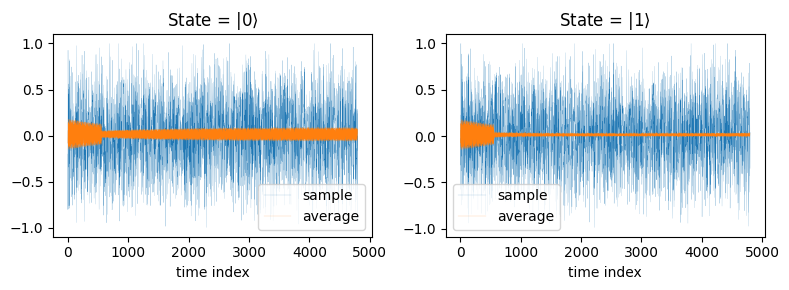

In [3]:
import matplotlib.pyplot as plt

rng = np.random.default_rng()
idx = [rng.choice(np.where(y == 0)[0]),
       rng.choice(np.where(y == 1)[0])]

titles = [fr"State = $|0\rangle$", fr"State = $|1\rangle$"]

t = np.arange(x.shape[1])

plt.figure(figsize=(8,3))

for i in [0,1]:
    plt.subplot(1,2,i+1)
    plt.plot(t, x[idx[i],:], label="sample", lw=0.1)
    plt.plot(t, np.mean(x[np.where(y==i)[0],:], axis=0), label="average", lw=0.1)
    plt.title(titles[i])
    plt.xlabel('time index')
    plt.legend()

plt.tight_layout()
plt.show()

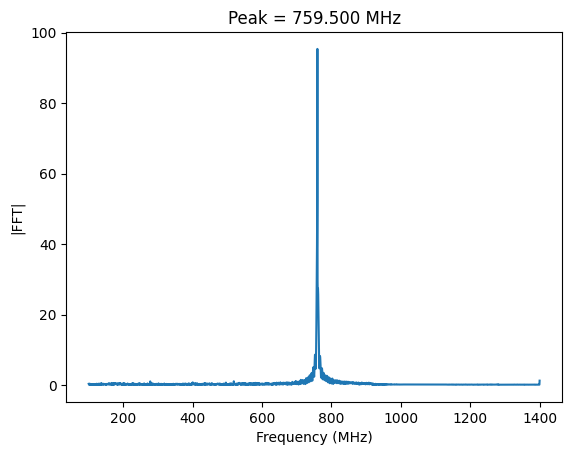

Demodulation frequency = 759.5 MHz


In [4]:
fs = 2.8e9
f_demod = find_demod_freq(x, fs, fmin=100e6, fmax=1.5e9)
print("Demodulation frequency =", f_demod/1e6, "MHz")

## 分割实验数据

In [5]:
import numpy as np

def demod_iq(x, f_demod, fs, phase=0.0):
    # x: (B,T) real
    t = np.arange(x.shape[1]) / fs
    I = x * np.cos(2*np.pi*f_demod*t + phase)
    Q = x * np.sin(2*np.pi*f_demod*t + phase)
    return np.stack([I, Q], axis=-1)  # (B,T,2)

def split_9to1(x, y, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y))
    rng.shuffle(idx)
    n_train = int(0.9 * len(y))
    tr, te = idx[:n_train], idx[n_train:]
    return x[tr], y[tr], x[te], y[te]

# 用法
# x.shape=(B,T), y.shape=(B,)
X = demod_iq(x, f_demod=f_demod, fs=fs, phase=0.0)  # (B,T,2)
X_train, y_train, X_test, y_test = split_9to1(X, y, seed=123)

保存分割后的实验数据

In [ ]:
import json
np.savez_compressed(
    os.path.join(dir, "IQ_featured_data"),
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
)

## 训练

data\readout_data\IQ_featured_data.npz

文件已生成，可以直接运行下方代码

如果需要添加新的训练模型，或者调整参数，可以修改

scripts\run_readout_all.py

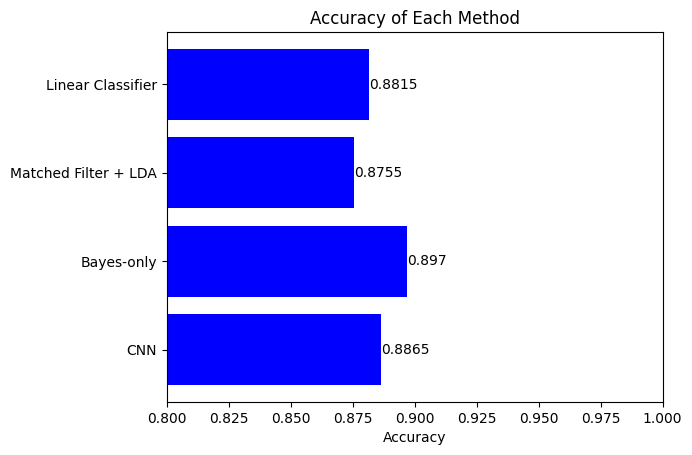

,acc,nll,time
Linear Classifier,0.8815,0.384172,19.868572
Matched Filter + LDA,0.8755,0.375987,20.278144
Bayes-only,0.8970,1.948521,NaN
CNN,0.8865,0.358590,194.666047


In [1]:
import subprocess
import json
import matplotlib.pyplot as plt
import pandas as pd 

# Run the script and capture output
# data_file = 'data/test_readout.npz'
data_file = "data/readout_data/IQ_featured_data.npz"
result = subprocess.run(
    ['python', '-m', 'scripts.run_readout_all', '--in_npz', data_file, 
     '--epochs=100'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True
)

if result.stderr == '':
    # Capture the results dictionary from the stdout (if printed by the script)
    json_output = result.stdout.split("All Results:")[-1].strip().replace("'", '"')
    results = json.loads(json_output)

    # Extract accuracies for plotting
    methods =list(results.keys())
    accuracies = [results[method]["acc"] for method in methods]
    nlls = [results[method]["nll"] for method in methods]

    # Plot the accuracies as a bar chart
    fig, ax = plt.subplots()
    bars = plt.barh(methods[::-1], accuracies[::-1], color="b")
    ax.bar_label(bars)
    ax.set_xlim((0.8, 1.0))
    ax.set_xlabel('Accuracy')
    ax.set_title('Accuracy of Each Method')
    # plt.grid(True, axis='x')
    plt.show()
    
    display( pd.DataFrame(results).transpose() )
else:
    print( result.stderr )
